In [1]:
# A narrativa comum sobre regressão linear é:
#   "encontre a linha que minimiza a soma dos quadrados dos erros"
#
# Mas a narrativa correta é:
#   "projete o vetor y no subespaço gerado pelas colunas de X"
#
# Formalmente:
#   Dado X (n×p) e y (n×1), queremos ŷ = X @ β tal que
#   o resíduo r = y - ŷ seja ortogonal ao espaço coluna de X.
#
# A condição de ortogonalidade:
#   Xᵀ(y - Xβ) = 0
#   Xᵀy = XᵀXβ
#   β = (XᵀX)⁻¹ Xᵀy       ← equação normal
#
# Isso é uma projeção ortogonal de y no Col(X).
# A matriz de projeção é: H = X(XᵀX)⁻¹Xᵀ  (hat matrix)
# ŷ = H @ y
#
# Conexão com SVD:
#   Se X = UΣVᵀ, então:
#   β = VΣ⁻¹Uᵀy   (mais estável numericamente que (XᵀX)⁻¹Xᵀy)
#
# Por que mínimos quadrados = projeção?
# ‖y - Xβ‖² é mínimo quando (y - Xβ) ⊥ Col(X).
# O vetor mais próximo de y no subespaço é sua projeção ortogonal.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [3]:
np.random.seed(88)

# dataset simples
n = 50
x_vals = np.linspace(0, 10, n)
y_true = 2.5 * x_vals + 1.0
y_obs = y_true + np.random.randn(n) * 2.5

# montar X com coluna de 1s (intercepto)
X = np.column_stack([np.ones(n), x_vals])   # shape (n, 2)
y = y_obs

# MÉTODO 1: equação normal direta
beta_normal = np.linalg.inv(X.T @ X) @ X.T @ y
print("Equação normal β = (XᵀX)⁻¹Xᵀy:")
print(f"  intercepto: {beta_normal[0]:.4f}  (verdadeiro: 1.0)")
print(f"  inclinação: {beta_normal[1]:.4f}  (verdadeiro: 2.5)")

# MÉTODO 2: via SVD (mais estável — evita inverter XᵀX)
U, s, Vt = np.linalg.svd(X, full_matrices=False)
beta_svd = Vt.T @ np.diag(1./s) @ U.T @ y
print(f"\nVia SVD β = VΣ⁻¹Uᵀy:")
print(f"  intercepto: {beta_svd[0]:.4f}")
print(f"  inclinação: {beta_svd[1]:.4f}")

# MÉTODO 3: numpy lstsq (usa SVD internamente)
beta_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print(f"\nnumpy lstsq: {beta_lstsq}")
print(f"Todos idênticos? {np.allclose(beta_normal, beta_svd)}")


Equação normal β = (XᵀX)⁻¹Xᵀy:
  intercepto: 1.7563  (verdadeiro: 1.0)
  inclinação: 2.3179  (verdadeiro: 2.5)

Via SVD β = VΣ⁻¹Uᵀy:
  intercepto: 1.7563
  inclinação: 2.3179

numpy lstsq: [1.75626089 2.31790106]
Todos idênticos? True


In [4]:
# A condição fundamental: resíduo ⊥ colunas de X

y_hat = X @ beta_normal
residuo = y - y_hat

# produto interno de cada coluna de X com o resíduo deve ser ≈ 0
print(f"\nXᵀ @ resíduo (deve ser ≈ 0):")
print(np.round(X.T @ residuo, 8))

# ============================================================
# PARTE 3 — Hat matrix (matriz de projeção)
# ============================================================
# H = X(XᵀX)⁻¹Xᵀ é uma projeção ortogonal sobre Col(X)
# Propriedades:
#   H² = H     (projeção idempotente: projetar duas vezes = projetar uma)
#   H = Hᵀ     (simétrica: projeção ortogonal)
#   ŷ = Hy     (aplica a projeção)

H = X @ np.linalg.inv(X.T @ X) @ X.T

print(f"\nHat matrix H — propriedades:")
print(f"  H² = H?   {np.allclose(H @ H, H)}")
print(f"  H = Hᵀ?   {np.allclose(H, H.T)}")
print(f"  ŷ = Hy?   {np.allclose(H @ y, y_hat)}")
print(f"  rank(H):  {np.linalg.matrix_rank(H)} (= número de colunas de X)")




Xᵀ @ resíduo (deve ser ≈ 0):
[0. 0.]

Hat matrix H — propriedades:
  H² = H?   True
  H = Hᵀ?   True
  ŷ = Hy?   True
  rank(H):  2 (= número de colunas de X)


In [5]:
# Quando colunas de X são linearmente dependentes,
# XᵀX é singular → equação normal sem solução única.
# SVD resolve: simplesmente zera os valores singulares pequenos.

# dataset com 3 features, uma delas sendo combinação das outras
n2 = 100
x1 = np.random.randn(n2)
x2 = np.random.randn(n2)
x3 = 2*x1 + 0.001*np.random.randn(n2)   # quase colinear com x1
y2 = 3*x1 + 2*x2 + np.random.randn(n2)*0.5

X2 = np.column_stack([np.ones(n2), x1, x2, x3])

print(f"\nMulticolinearidade:")
print(f"  det(XᵀX) = {np.linalg.det(X2.T @ X2):.4e}  (próximo de 0!)")
print(f"  valores singulares de X: {np.linalg.svd(X2, compute_uv=False).round(2)}")

# lstsq lida bem (via SVD), inv(XᵀX) explode
beta_mc = np.linalg.lstsq(X2, y2, rcond=None)[0]
print(f"  β via lstsq:   {beta_mc.round(3)}")



Multicolinearidade:
  det(XᵀX) = 9.8324e+01  (próximo de 0!)
  valores singulares de X: [20.14 10.17  9.74  0.  ]
  β via lstsq:   [ 0.076 15.827  1.976 -6.389]


In [6]:
# R² = cos²(ângulo entre y e ŷ no espaço centrado)
#    = variância explicada / variância total
#    = ‖ŷ - ȳ‖² / ‖y - ȳ‖²

y_bar = np.mean(y)
SS_tot = np.sum((y - y_bar)**2)    # variância total
SS_res = np.sum(residuo**2)        # variância do resíduo
SS_reg = np.sum((y_hat - y_bar)**2)  # variância explicada

R2 = 1 - SS_res/SS_tot
print(f"\nR² = {R2:.4f}")
print(f"SS_tot = SS_reg + SS_res? {np.isclose(SS_tot, SS_reg + SS_res)}")

# R² é literalmente o cos² entre y_centralizado e ŷ_centralizado
cos2 = np.dot(y_hat - y_bar, y - y_bar)**2 / (
       np.linalg.norm(y_hat - y_bar)**2 * np.linalg.norm(y - y_bar)**2)
print(f"R² = cos²(ângulo): {cos2:.4f}  ← mesma coisa")



R² = 0.8939
SS_tot = SS_reg + SS_res? True
R² = cos²(ângulo): 0.8939  ← mesma coisa


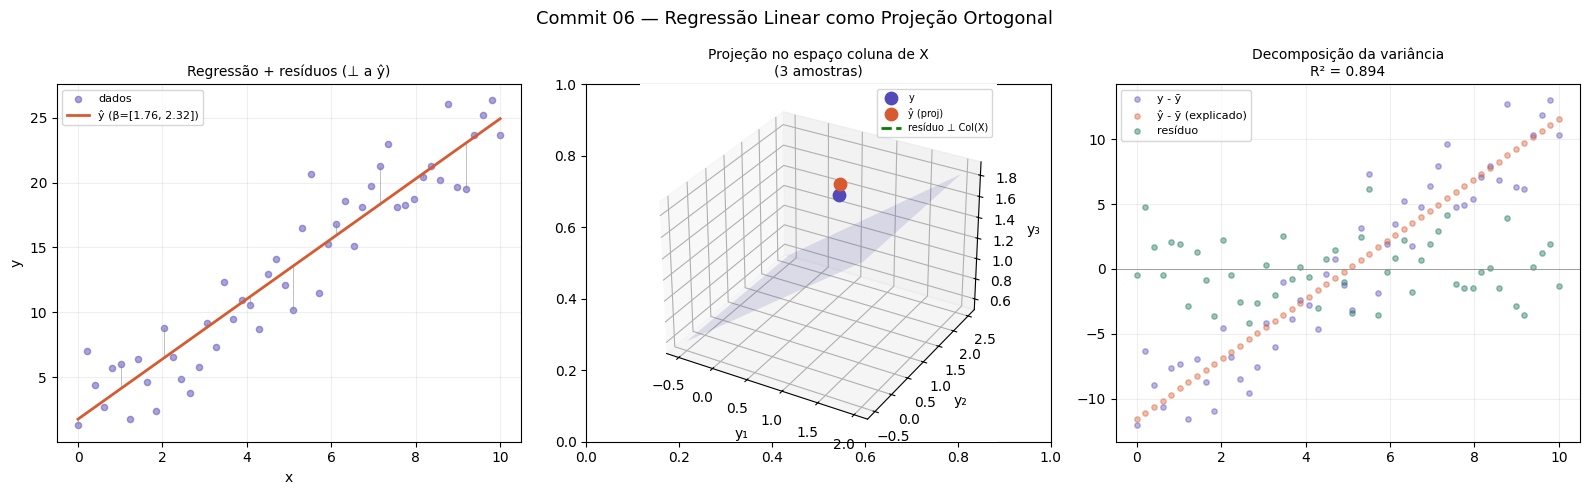

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Commit 06 — Regressão Linear como Projeção Ortogonal", fontsize=13)

# Plot 1: regressão clássica com resíduos
ax = axes[0]
ax.scatter(x_vals, y, alpha=0.5, s=20, color='#534AB7', label='dados')
ax.plot(x_vals, y_hat, color='#D85A30', lw=2, label=f'ŷ (β=[{beta_normal[0]:.2f}, {beta_normal[1]:.2f}])')
for i in range(0, n, 5):
    ax.plot([x_vals[i], x_vals[i]], [y[i], y_hat[i]], 'gray', lw=0.7, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Regressão + resíduos (⊥ a ŷ)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Plot 2: geometria em R³ (3 amostras, 2 features)
# Para visualizar a projeção no espaço de y
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.set_title("Projeção no espaço coluna de X\n(3 amostras)", fontsize=10)

# versão 3D com 3 pontos para visualizar
X3 = np.array([[1., 0.], [1., 1.], [1., 2.]])
y3 = np.array([0.5, 2.0, 1.5])
b3 = np.linalg.lstsq(X3, y3, rcond=None)[0]
yhat3 = X3 @ b3
res3 = y3 - yhat3

# plano Col(X3)
u, v = np.linspace(-0.5, 2, 10), np.linspace(-0.5, 2.5, 10)
UU, VV = np.meshgrid(u, v)
Zplane = b3[0]*np.ones_like(UU) + b3[1]*UU
ax2.plot_surface(UU, VV, Zplane, alpha=0.15, color='#534AB7')

ax2.scatter(*y3, color='#534AB7', s=80, zorder=5, label='y')
ax2.scatter(*yhat3, color='#D85A30', s=80, zorder=5, label='ŷ (proj)')
ax2.plot([y3[0], yhat3[0]], [y3[1], yhat3[1]], [y3[2], yhat3[2]],
         'g--', lw=2, label='resíduo ⊥ Col(X)')
ax2.set_xlabel('y₁'); ax2.set_ylabel('y₂'); ax2.set_zlabel('y₃')
ax2.legend(fontsize=7)

# Plot 3: decomposição de variância (SS)
ax3 = axes[2]
ax3.scatter(x_vals, y - y_bar, alpha=0.4, s=15, color='#534AB7', label='y - ȳ')
ax3.scatter(x_vals, y_hat - y_bar, alpha=0.4, s=15, color='#D85A30', label='ŷ - ȳ (explicado)')
ax3.scatter(x_vals, residuo, alpha=0.4, s=15, color='#0F6E56', label='resíduo')
ax3.axhline(0, color='gray', lw=0.5)
ax3.set_title(f"Decomposição da variância\nR² = {R2:.3f}", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../assets/06_regression_projection.png', dpi=150, bbox_inches='tight')
plt.show()
